In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from medmnist import ChestMNIST
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score

In [24]:
import torchvision.transforms as transforms
from torch.utils.data import Subset

torch.manual_seed(42)
np.random.seed(42)

transform_train = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

transform_test = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

train_dataset = ChestMNIST(split='train', download=True, size=64, transform=transform_train)
val_dataset   = ChestMNIST(split='val',   download=True, size=64, transform=transform_test)
test_dataset  = ChestMNIST(split='test',  download=True, size=64, transform=transform_test)

indices_10k = torch.load('models/indices_10k.pth')
train_dataset = Subset(train_dataset, indices_10k)
val_dataset   = Subset(val_dataset,   range(2000))
test_dataset  = Subset(test_dataset,  range(3000))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          generator=torch.Generator().manual_seed(42))
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print("Data chargée")

Data chargée


In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

# Charger ResNet18 pré-entraîné
model = models.resnet18(pretrained=True)

# ResNet attend 3 canaux, on adapte la première couche pour 1 canal (grayscale)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Remplacer la dernière couche pour 14 classes
model.fc = nn.Linear(model.fc.in_features, 14)

model = model.to(device)
print("ResNet18 chargé ")

Device : cpu
ResNet18 chargé 


c:\Users\ervin\Documents\efrei\deep-learning\.venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ervin\Documents\efrei\deep-learning\.venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [26]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
    def forward(self, inputs, targets):
        bce_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

criterion = FocalLoss(gamma=2.0, alpha=0.25)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
print("Setup avec Focal Loss ")

Setup avec Focal Loss 


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=6):
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    patience = 3
    counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.float().to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                labels = labels.float().to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_loss = val_loss / len(val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'models/cnn_transfer_best.pth')
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping à l'epoch {epoch+1}")
                break

    # Recharger le meilleur modèle automatiquement
    model.load_state_dict(torch.load('models/cnn_transfer_best.pth', map_location=device))
    print("Meilleur modèle rechargé ")

    return train_losses, val_losses

train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=6)

Epoch [1/6] | Train Loss: 0.0148 | Val Loss: 0.0381
Epoch [2/6] | Train Loss: 0.0135 | Val Loss: 0.0188
Epoch [3/6] | Train Loss: 0.0133 | Val Loss: 0.0131
Epoch [4/6] | Train Loss: 0.0131 | Val Loss: 0.0122
Epoch [5/6] | Train Loss: 0.0133 | Val Loss: 0.0140
Epoch [6/6] | Train Loss: 0.0131 | Val Loss: 0.0199
Meilleur modèle rechargé ✅


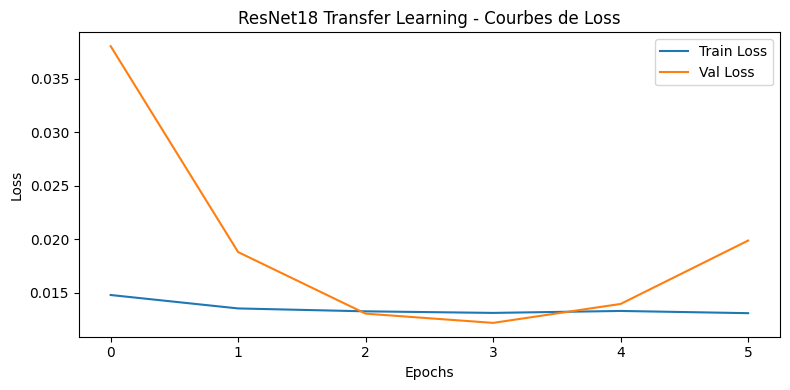

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ResNet18 Transfer Learning - Courbes de Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score

label_names = ['atelectasis', 'cardiomegaly', 'effusion', 'infiltration',
               'mass', 'nodule', 'pneumonia', 'pneumothorax',
               'consolidation', 'edema', 'emphysema', 'fibrosis', 'pleural', 'hernia']

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(model(imgs))
        all_preds.append(outputs.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
all_preds_binary = (all_preds >= 0.1).astype(int)

print("=" * 65)
print(f"{'Pathologie':<20} | {'AUC':>6} | {'F1':>6} | {'Recall':>6} | {'Precision':>9}")
print("=" * 65)

aucs, f1s, recalls, precisions = [], [], [], []
for i, name in enumerate(label_names):
    auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
    f1 = f1_score(all_labels[:, i], all_preds_binary[:, i], zero_division=0)
    recall = recall_score(all_labels[:, i], all_preds_binary[:, i], zero_division=0)
    precision = precision_score(all_labels[:, i], all_preds_binary[:, i], zero_division=0)
    aucs.append(auc)
    f1s.append(f1)
    recalls.append(recall)
    precisions.append(precision)
    print(f"{name:<20} | {auc:>6.4f} | {f1:>6.4f} | {recall:>6.4f} | {precision:>9.4f}")

print("=" * 65)
print(f"{'Moyenne':<20} | {np.mean(aucs):>6.4f} | {np.mean(f1s):>6.4f} | {np.mean(recalls):>6.4f} | {np.mean(precisions):>9.4f}")

torch.save(model.state_dict(), 'models/cnn_transfer.pth')
print("\nModèle sauvegardé ")

Pathologie           |    AUC |     F1 | Recall | Precision
atelectasis          | 0.6520 | 0.2031 | 1.0000 |    0.1130
cardiomegaly         | 0.6003 | 0.0566 | 0.9884 |    0.0291
effusion             | 0.7036 | 0.2343 | 1.0000 |    0.1327
infiltration         | 0.6321 | 0.3022 | 1.0000 |    0.1780
mass                 | 0.5092 | 0.0989 | 1.0000 |    0.0520
nodule               | 0.5155 | 0.1067 | 1.0000 |    0.0563
pneumonia            | 0.6576 | 0.0221 | 1.0000 |    0.0112
pneumothorax         | 0.5707 | 0.0928 | 1.0000 |    0.0487
consolidation        | 0.7052 | 0.0794 | 1.0000 |    0.0413
edema                | 0.7867 | 0.0435 | 1.0000 |    0.0222
emphysema            | 0.5480 | 0.0437 | 1.0000 |    0.0223
fibrosis             | 0.5840 | 0.0263 | 1.0000 |    0.0133
pleural              | 0.5652 | 0.0601 | 1.0000 |    0.0310
hernia               | 0.3563 | 0.0000 | 0.0000 |    0.0000
Moyenne              | 0.5990 | 0.0978 | 0.9277 |    0.0537

Modèle sauvegardé 
